In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno

In [2]:
%run '/content/pandas_missing_extension.ipynb'

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=UpSetPlot-0.9.0-py3-none-any.whl size=24839 sha256=a4315f6fcdb0e4b2c581be5ec0b07ace77f0487d095b133d437fc435fdee7e1f
  Stored in directory: /root/.cache/pip/wheels/7b/ce/88/1d0bce5b2680165c29c3e68416325e79674d5a9f422d037996
Successfully built upsetplot


In [3]:
!pip install nhanes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.6 MB/s eta 0:00:00


In [4]:
import nhanes.load
nhanes_df = nhanes.load.load_NHANES_data(year="2017-2018")
nhanes_df

,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,TypeOfMilkFirstFed1Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
SEQN,,,,,,,,,,,,,,,,,,,,,
93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102952.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.0,0.0,Never
102953.0,Fair or,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,65.0,218.0,0.0,Never
102954.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,66.0,150.0,0.0,Never


In [6]:
nhanes_df = nhanes_df[[
        'GeneralHealthCondition',
        'Gender',
        'AgeStoppedBreastfeedingdays', 'AgeFirstFedFormuladays',
       'AgeStoppedReceivingFormuladays', 'AgeStartedOtherFoodbeverage',
       'AgeFirstFedMilkdays']]
nhanes_df

,GeneralHealthCondition,Gender,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays
SEQN,,,,,,,
93703.0,NaN,Female,273.0,1.0,365.0,152.0,365.0
93704.0,NaN,Male,60.0,3.0,365.0,126.0,365.0
93705.0,Good,Female,NaN,NaN,NaN,NaN,NaN
93706.0,Very good,Male,NaN,NaN,NaN,NaN,NaN
93707.0,Good,Male,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
102952.0,Very good,Female,NaN,NaN,NaN,NaN,NaN
102953.0,Fair or,Male,NaN,NaN,NaN,NaN,NaN
102954.0,Good,Female,NaN,NaN,NaN,NaN,NaN


# 01. ANALISIS DE FALTANTES POR VARIABLES

In [7]:
nhanes_df.missing.missing_variable_summary()

,variable,n_missing,n_cases,pct_missing
0,GeneralHealthCondition,2402,8366,28.711451
1,Gender,0,8366,0.000000
2,AgeStoppedBreastfeedingdays,7504,8366,89.696390
3,AgeFirstFedFormuladays,7289,8366,87.126464
4,AgeStoppedReceivingFormuladays,7475,8366,89.349749
5,AgeStartedOtherFoodbeverage,7289,8366,87.126464
6,AgeFirstFedMilkdays,7300,8366,87.257949


In [8]:
nhanes_df.missing.missing_variable_table()

,n_missing_in_variable,n_variables,pct_variables
0,7289,2,28.571429
1,0,1,14.285714
2,2402,1,14.285714
3,7300,1,14.285714
4,7475,1,14.285714
5,7504,1,14.285714


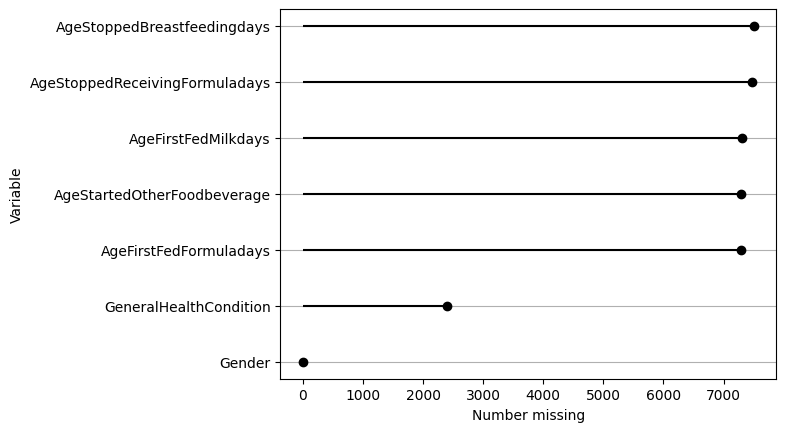

In [9]:
nhanes_df.missing.missing_variable_plot()

<Axes: >

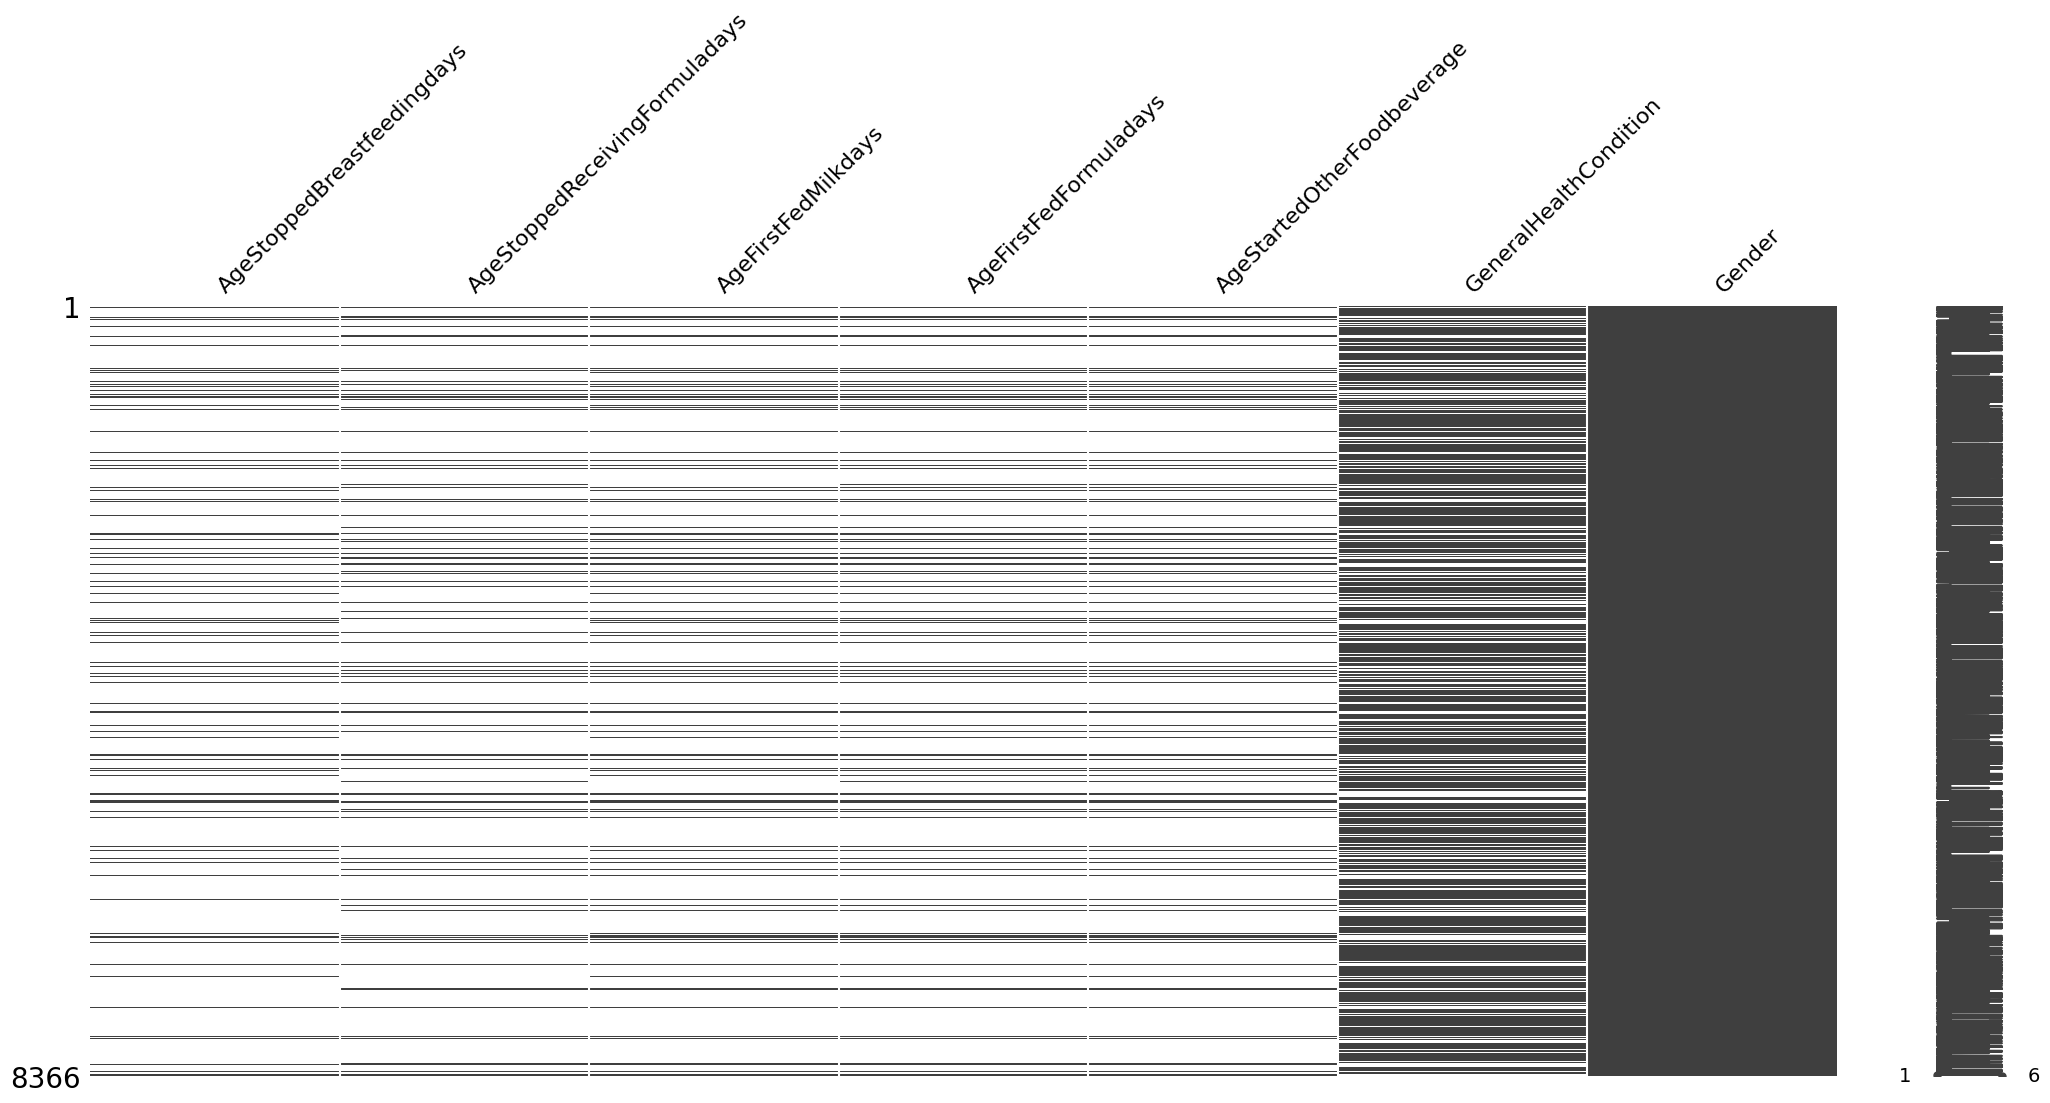

In [10]:
(
    nhanes_df
    .missing.sort_variables_by_missingness()
    .pipe(missingno.matrix)
)

# 02. IMPUTACIÓN DE AgeFirstFedFormuladays

## 02.1. UTILIZANDO LA MEDIA:

In [11]:
round(nhanes_df.AgeFirstFedFormuladays.mean())

14908

In [12]:
nh_agefff_mean = nhanes_df.copy()

In [13]:
nh_agefff_mean['AgeFirstFedFormuladays'] = nh_agefff_mean['AgeFirstFedFormuladays'].fillna(nh_agefff_mean['AgeFirstFedFormuladays'].mean())
sorted_age_df = nh_agefff_mean.sort_values(
    by=['AgeFirstFedFormuladays'],
    ascending=False
)
sorted_age_df

,GeneralHealthCondition,Gender,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays
SEQN,,,,,,,
94671.0,NaN,Male,NaN,9.999990e+05,365.0,365.0,365.0
94709.0,NaN,Male,999999.0,9.999990e+05,999999.0,999999.0,NaN
93802.0,NaN,Female,NaN,9.999990e+05,547.0,243.0,365.0
94846.0,NaN,Male,NaN,9.999990e+05,999999.0,999999.0,NaN
100990.0,NaN,Male,NaN,9.999990e+05,365.0,91.0,365.0
...,...,...,...,...,...,...,...
102812.0,NaN,Female,730.0,5.397605e-79,NaN,182.0,365.0
98478.0,NaN,Female,730.0,5.397605e-79,NaN,182.0,730.0
100220.0,NaN,Female,547.0,5.397605e-79,NaN,182.0,547.0


In [14]:
print(f" media original : {nhanes_df['AgeFirstFedFormuladays'].mean()} | media sin nulos : {nh_agefff_mean['AgeFirstFedFormuladays'].mean()}")

 media original : 14907.852367688023 | media sin nulos : 14907.852367688025


## 02.2. UTILIZANDO FFILL

In [16]:
nh_agefff_ffill = nhanes_df.copy()

In [17]:
nh_agefff_ffill['AgeFirstFedFormuladays'] = nh_agefff_ffill['AgeFirstFedFormuladays'].ffill()
sorted_age_ffill = nh_agefff_ffill.sort_values(
    by=['AgeFirstFedFormuladays'],
    ascending=False
)
sorted_age_ffill

,GeneralHealthCondition,Gender,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays
SEQN,,,,,,,
94329.0,NaN,Female,NaN,9.999990e+05,999999.0,999999.0,NaN
94709.0,NaN,Male,999999.0,9.999990e+05,999999.0,999999.0,NaN
97819.0,Good,Female,NaN,9.999990e+05,NaN,NaN,NaN
94848.0,Good,Female,NaN,9.999990e+05,NaN,NaN,NaN
97464.0,Poor?,Male,NaN,9.999990e+05,NaN,NaN,NaN
...,...,...,...,...,...,...,...
96253.0,Good,Female,NaN,5.397605e-79,NaN,NaN,NaN
96254.0,NaN,Male,365.0,5.397605e-79,NaN,152.0,365.0
98400.0,NaN,Male,NaN,5.397605e-79,NaN,NaN,NaN


In [21]:
print(f" media original : {nhanes_df['AgeFirstFedFormuladays'].mean()} | media sin nulos : {nh_agefff_ffill['AgeFirstFedFormuladays'].mean()}")

 media original : 14907.852367688023 | media sin nulos : 9375.575902462348


## 02.3. UTILIZANDO BFILL

In [25]:
nh_agefff_bfill = nhanes_df.copy()

In [26]:
nh_agefff_bfill['AgeFirstFedFormuladays'] = nh_agefff_bfill['AgeFirstFedFormuladays'].bfill()
sorted_age_bfill = nh_agefff_bfill.sort_values(
    by=['AgeFirstFedFormuladays'],
    ascending=False
)
sorted_age_bfill

,GeneralHealthCondition,Gender,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays
SEQN,,,,,,,
94702.0,Fair or,Female,NaN,999999.0,NaN,NaN,NaN
97200.0,Very good,Male,NaN,999999.0,NaN,NaN,NaN
93799.0,Good,Male,NaN,999999.0,NaN,NaN,NaN
93800.0,Very good,Female,NaN,999999.0,NaN,NaN,NaN
93801.0,Very good,Male,NaN,999999.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...
102952.0,Very good,Female,NaN,NaN,NaN,NaN,NaN
102953.0,Fair or,Male,NaN,NaN,NaN,NaN,NaN
102954.0,Good,Female,NaN,NaN,NaN,NaN,NaN


In [27]:
print(f" media original : {nhanes_df['AgeFirstFedFormuladays'].mean()} | media sin nulos : {nh_agefff_bfill['AgeFirstFedFormuladays'].mean()}")

 media original : 14907.852367688023 | media sin nulos : 14885.365865327114


## 02.4. UTILIZANDO INTERPOLATE:

In [31]:
nh_agefff_interpolate = nhanes_df.copy()

In [32]:
nh_agefff_interpolate['AgeFirstFedFormuladays'] = nh_agefff_interpolate['AgeFirstFedFormuladays'].interpolate()
sorted_age_interpolate = nh_agefff_interpolate.sort_values(
    by=['AgeFirstFedFormuladays'],
    ascending=False
)
sorted_age_interpolate

,GeneralHealthCondition,Gender,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays
SEQN,,,,,,,
100773.0,NaN,Male,NaN,9.999990e+05,730.0,999999.0,NaN
94846.0,NaN,Male,NaN,9.999990e+05,999999.0,999999.0,NaN
97202.0,NaN,Male,NaN,9.999990e+05,999999.0,999999.0,NaN
94709.0,NaN,Male,999999.0,9.999990e+05,999999.0,999999.0,NaN
99406.0,NaN,Female,NaN,9.999990e+05,999999.0,999999.0,NaN
...,...,...,...,...,...,...,...
99939.0,Very good,Female,NaN,5.397605e-79,NaN,NaN,NaN
99940.0,NaN,Male,NaN,5.397605e-79,NaN,NaN,NaN
99941.0,Fair or,Female,NaN,5.397605e-79,NaN,NaN,NaN


In [33]:
print(f" media original : {nhanes_df['AgeFirstFedFormuladays'].mean()} | media sin nulos : {nh_agefff_interpolate['AgeFirstFedFormuladays'].mean()}")

 media original : 14907.852367688023 | media sin nulos : 12126.049904374851
